**IMPORT REQUIRED LIBRARIES**

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

**LOADING DATA FROM CSV_FILE**

In [98]:
df = pd.read_csv("/content/phone_addiction_dataset.csv")

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       6000 non-null   object 
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   object 
 3   Location                   6000 non-null   object 
 4   Daily_Usage_Hours          6000 non-null   float64
 5   Sleep_Hours                6000 non-null   float64
 6   Interllectual_Performance  6000 non-null   int64  
 7   Social_Interactions        6000 non-null   int64  
 8   Exercise_Hours             6000 non-null   float64
 9   Anxiety_Level              6000 non-null   int64  
 10  Depression_Level           6000 non-null   int64  
 11  Self_Esteem                6000 non-null   int64  
 12  Screen_Time_Before_Bed     6000 non-null   float64
 13  Phone_Checks_Per_Day       6000 non-null   int64

In [100]:
df.head()

,Name,Age,Gender,Location,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,Shannon Francis,13,Female,Hansonfort,4.0,6.1,78,5,0.1,10,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,Scott Rodriguez,17,Female,Theodorefort,5.5,6.5,70,5,0.0,3,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,Adrian Knox,13,Other,Lindseystad,5.8,5.5,93,8,0.8,2,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,Brittany Hamilton,18,Female,West Anthony,3.1,3.9,78,8,1.6,9,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,Steven Smith,14,Other,Port Lindsaystad,2.5,6.7,56,4,1.1,1,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [101]:
df.shape

(6000, 22)

<Axes: >

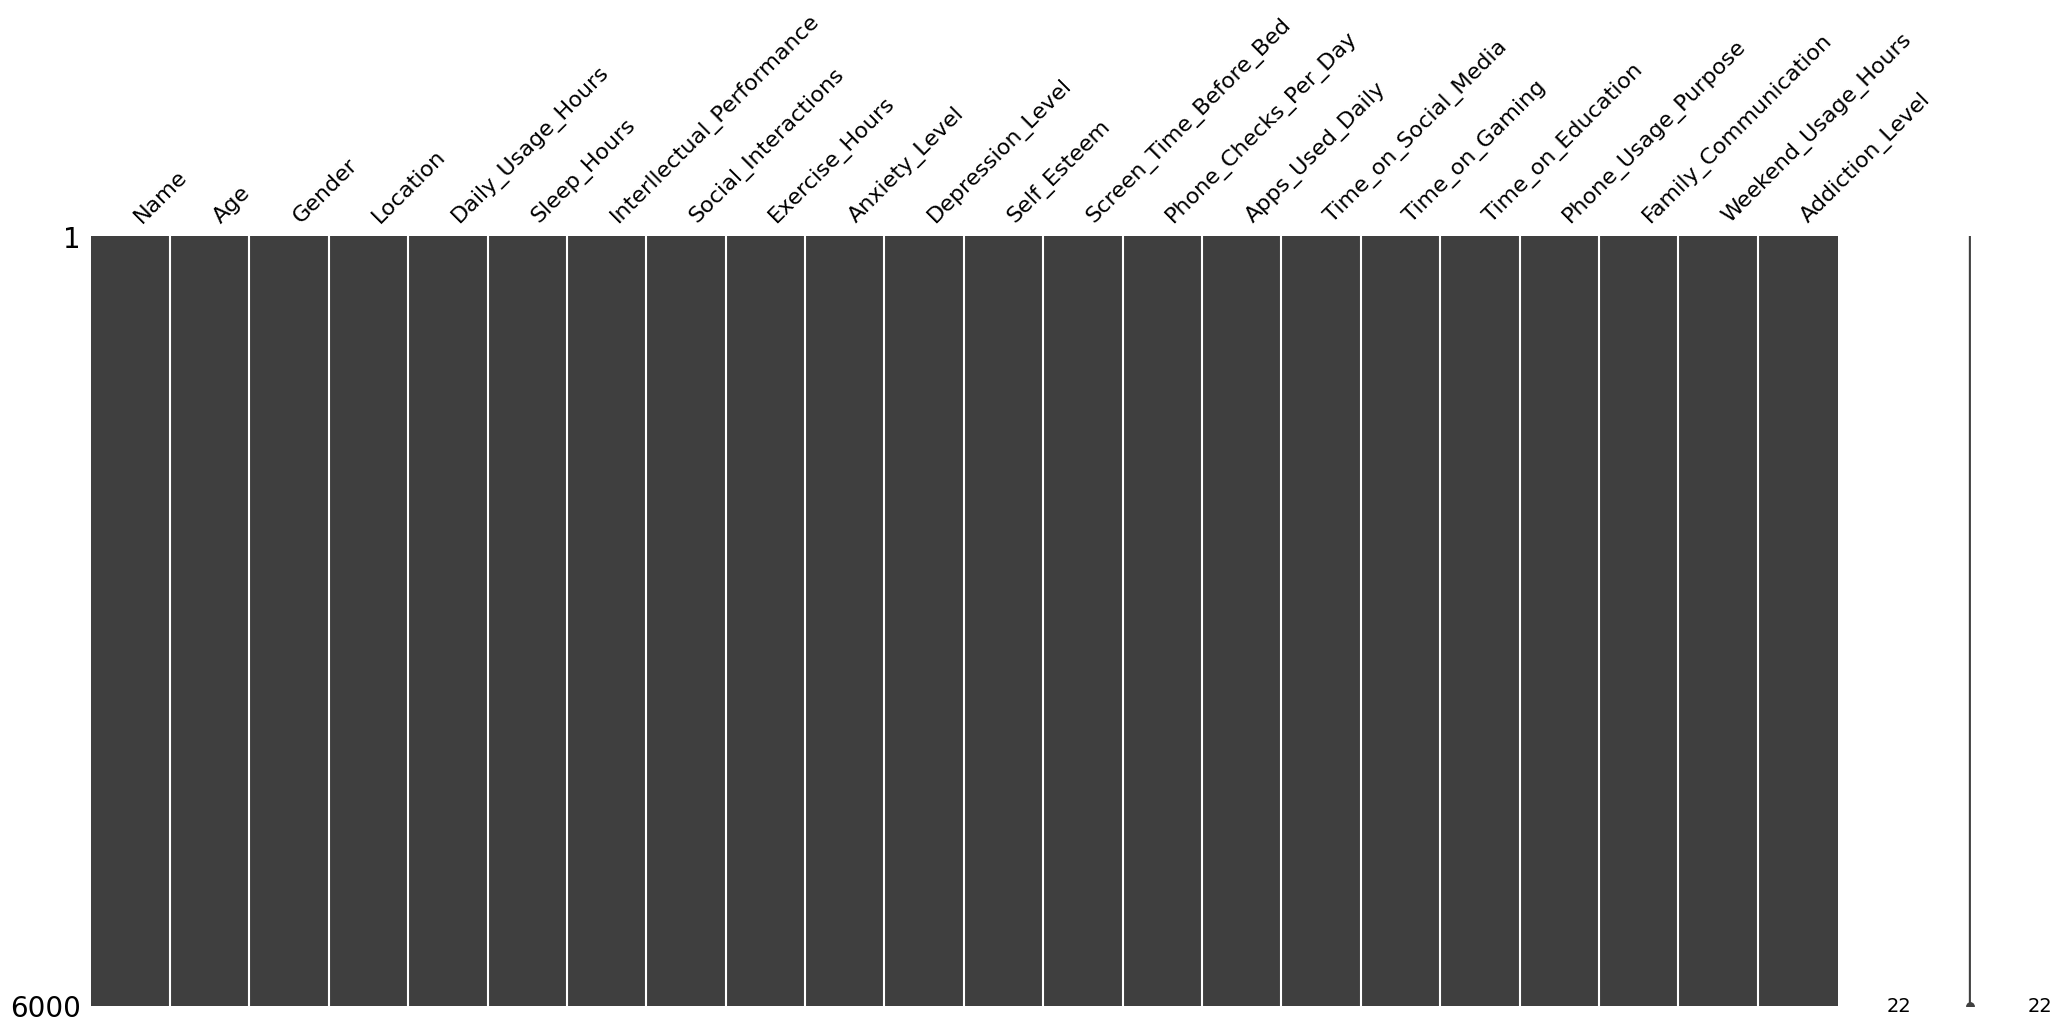

In [102]:
import missingno as msn
msn.matrix(df)

In [103]:
df = df.drop(columns=["Name","Location"])

In [104]:
df.head()

,Age,Gender,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,Female,4.0,6.1,78,5,0.1,10,3,8,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,17,Female,5.5,6.5,70,5,0.0,3,7,3,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,13,Other,5.8,5.5,93,8,0.8,2,3,10,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,18,Female,3.1,3.9,78,8,1.6,9,10,3,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,14,Other,2.5,6.7,56,4,1.1,1,5,1,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6000 non-null   int64  
 1   Gender                     6000 non-null   object 
 2   Daily_Usage_Hours          6000 non-null   float64
 3   Sleep_Hours                6000 non-null   float64
 4   Interllectual_Performance  6000 non-null   int64  
 5   Social_Interactions        6000 non-null   int64  
 6   Exercise_Hours             6000 non-null   float64
 7   Anxiety_Level              6000 non-null   int64  
 8   Depression_Level           6000 non-null   int64  
 9   Self_Esteem                6000 non-null   int64  
 10  Screen_Time_Before_Bed     6000 non-null   float64
 11  Phone_Checks_Per_Day       6000 non-null   int64  
 12  Apps_Used_Daily            6000 non-null   int64  
 13  Time_on_Social_Media       6000 non-null   float

In [106]:
df.shape

(6000, 20)

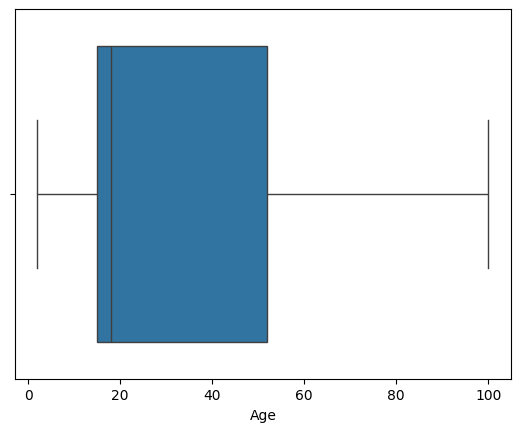

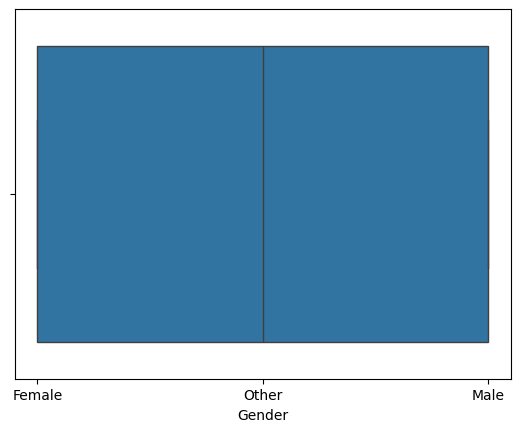

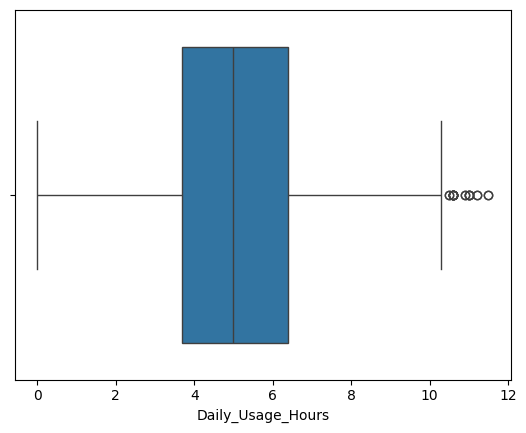

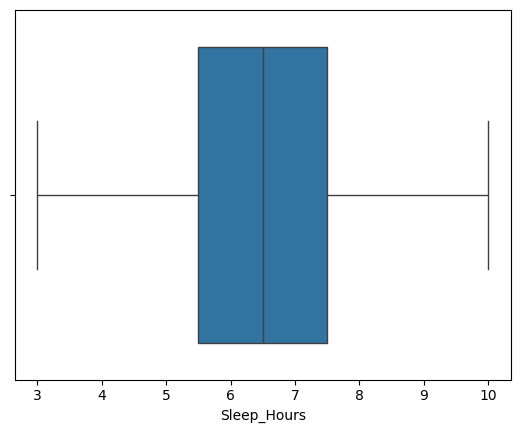

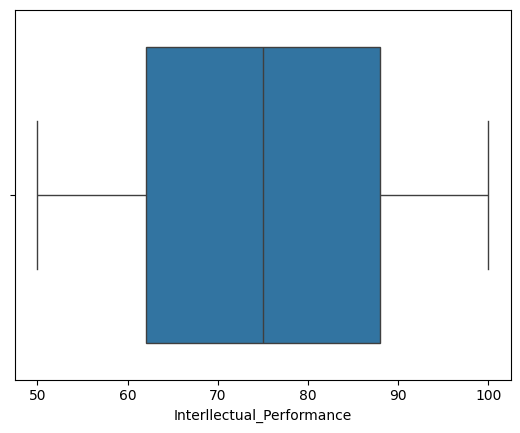

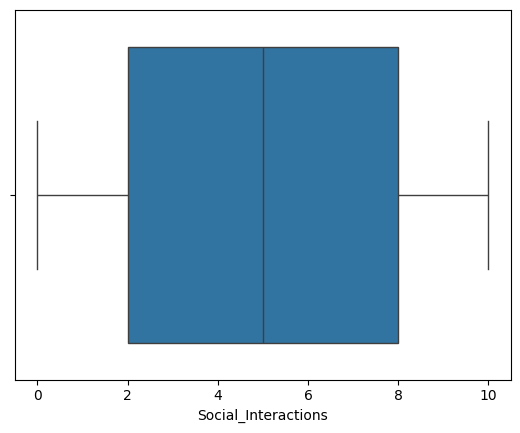

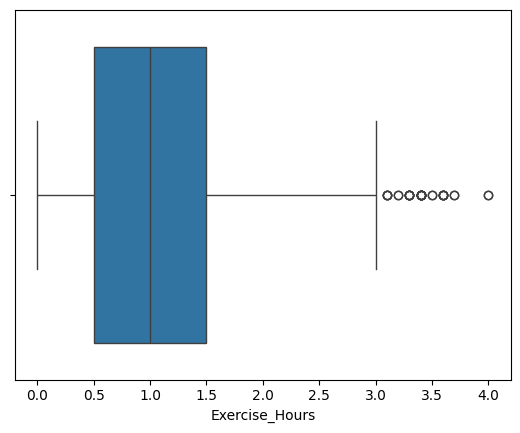

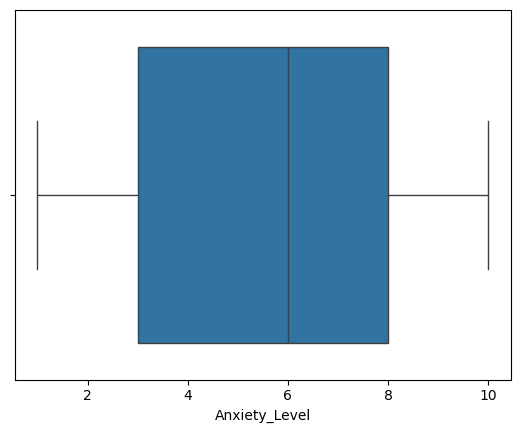

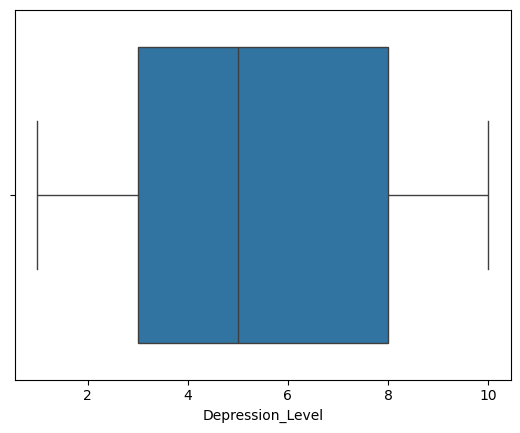

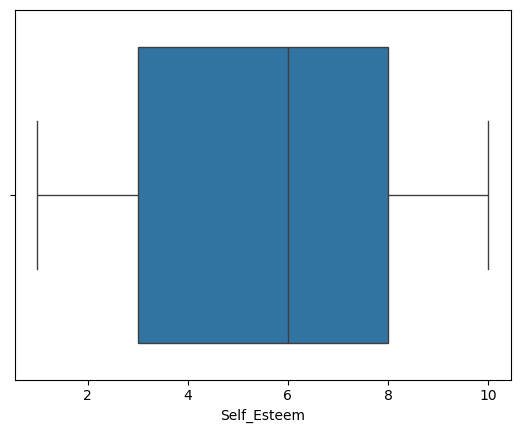

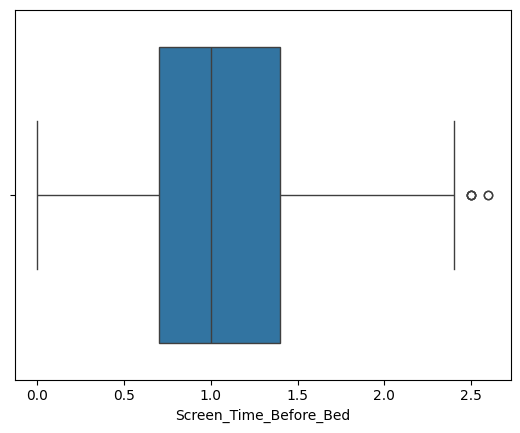

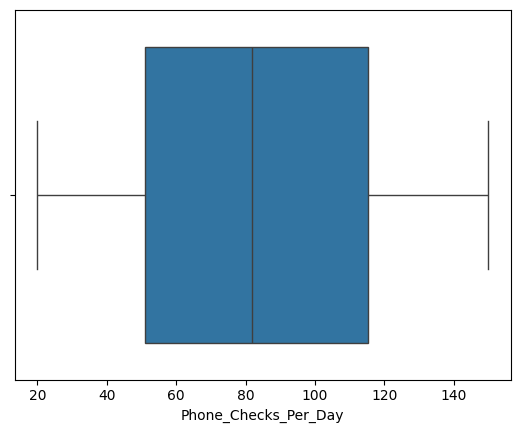

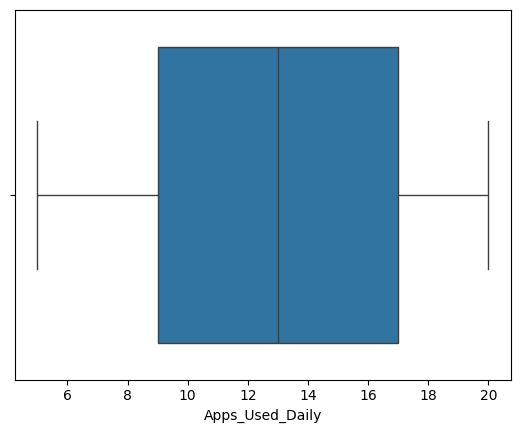

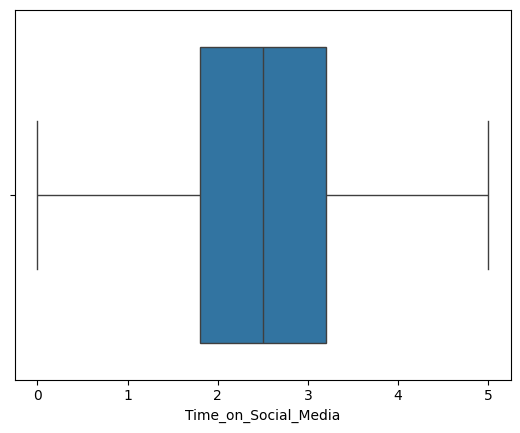

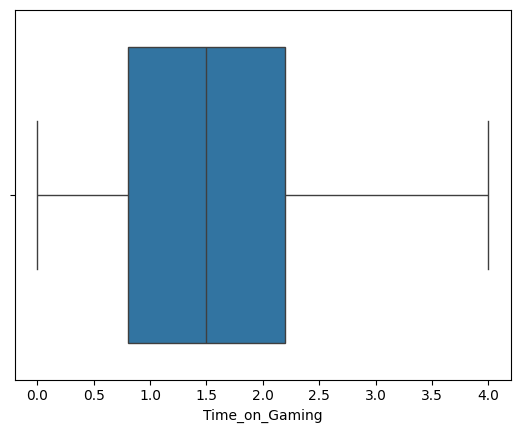

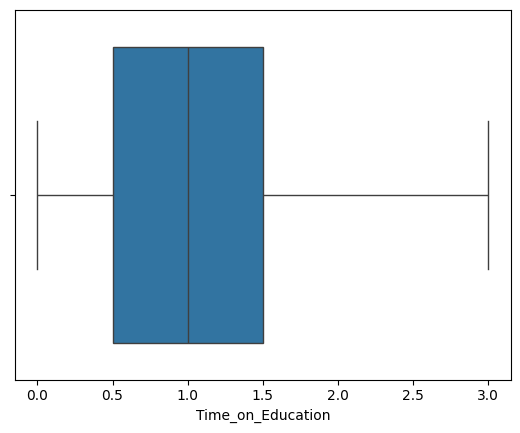

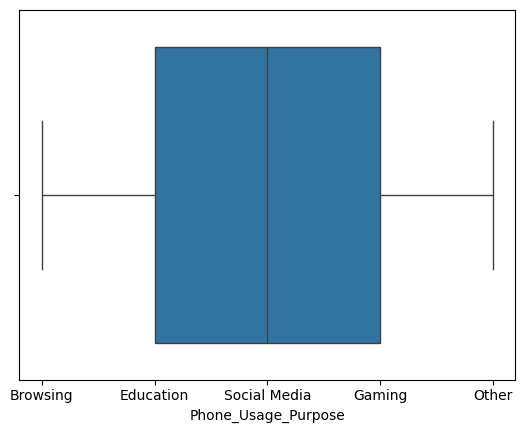

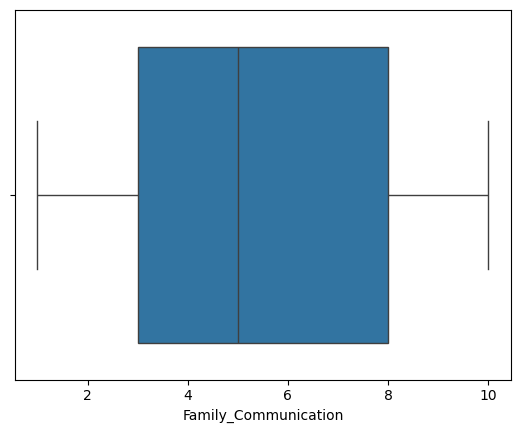

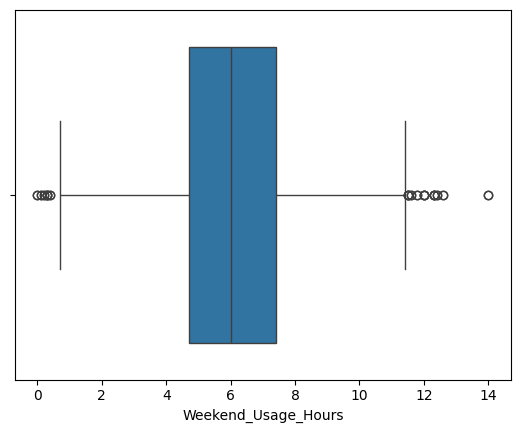

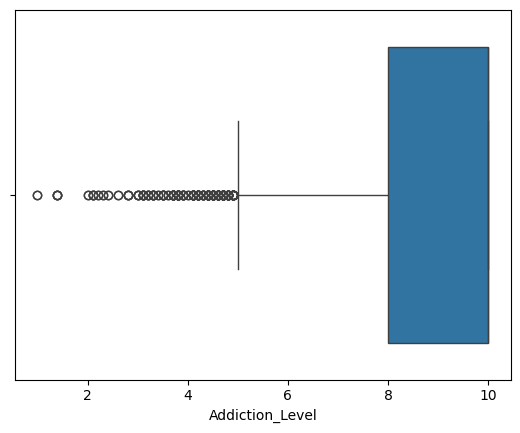

In [107]:
sns.boxplot(df,x="Age")
plt.show()
sns.boxplot(df,x="Gender")
plt.show()
sns.boxplot(df,x="Daily_Usage_Hours")
plt.show()
sns.boxplot(df,x="Sleep_Hours")
plt.show()
sns.boxplot(df,x="Interllectual_Performance")
plt.show()
sns.boxplot(df,x="Social_Interactions")
plt.show()
sns.boxplot(df,x="Exercise_Hours")
plt.show()
sns.boxplot(df,x="Anxiety_Level")
plt.show()
sns.boxplot(df,x="Depression_Level")
plt.show()
sns.boxplot(df,x="Self_Esteem")
plt.show()
sns.boxplot(df,x="Screen_Time_Before_Bed")
plt.show()
sns.boxplot(df,x="Phone_Checks_Per_Day")
plt.show()
sns.boxplot(df,x="Apps_Used_Daily")
plt.show()
sns.boxplot(df,x="Time_on_Social_Media")
plt.show()
sns.boxplot(df,x="Time_on_Gaming")
plt.show()
sns.boxplot(df,x="Time_on_Education")
plt.show()
sns.boxplot(df,x="Phone_Usage_Purpose")
plt.show()
sns.boxplot(df,x="Family_Communication")
plt.show()
sns.boxplot(df,x="Weekend_Usage_Hours")
plt.show()
sns.boxplot(df,x="Addiction_Level")
plt.show()

In [108]:
df.head()

,Age,Gender,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,Female,4.0,6.1,78,5,0.1,10,3,8,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,17,Female,5.5,6.5,70,5,0.0,3,7,3,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,13,Other,5.8,5.5,93,8,0.8,2,3,10,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,18,Female,3.1,3.9,78,8,1.6,9,10,3,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,14,Other,2.5,6.7,56,4,1.1,1,5,1,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [109]:
df.shape

(6000, 20)

In [110]:
df["Addiction_Level"]=df["Addiction_Level"].fillna(df["Addiction_Level"].median())

In [111]:
df["Weekend_Usage_Hours"]=df["Weekend_Usage_Hours"].fillna(df["Weekend_Usage_Hours"].median())

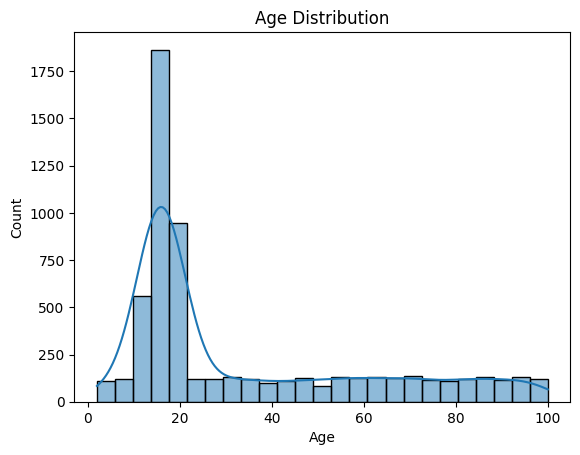

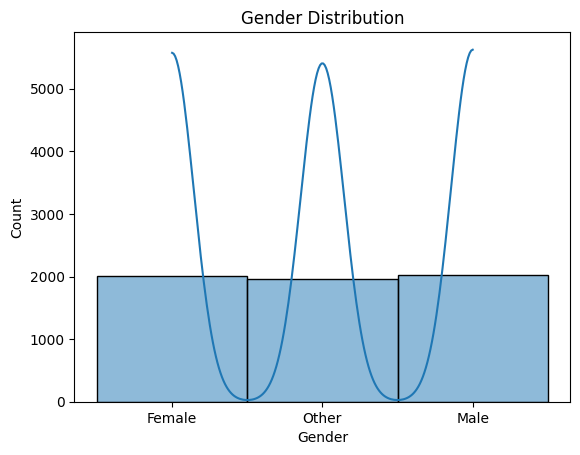

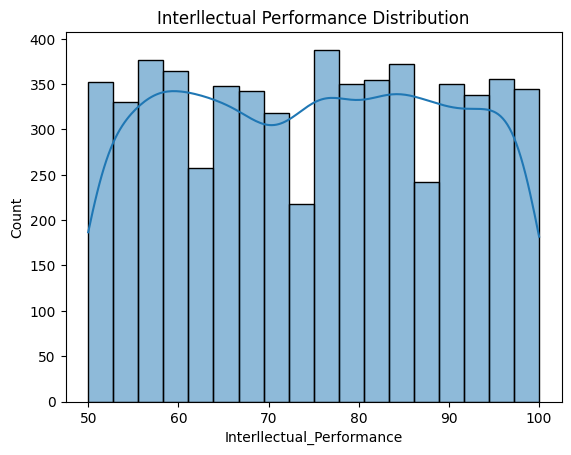

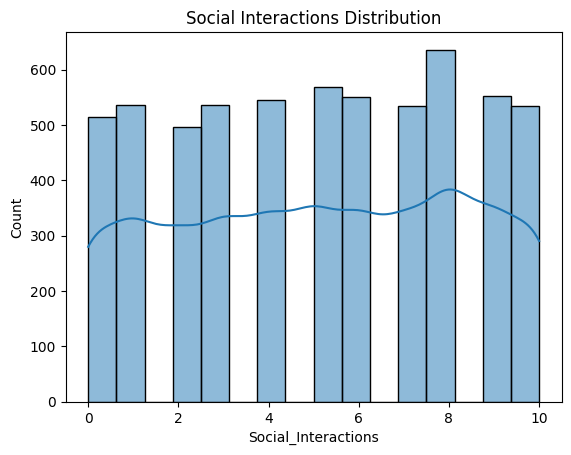

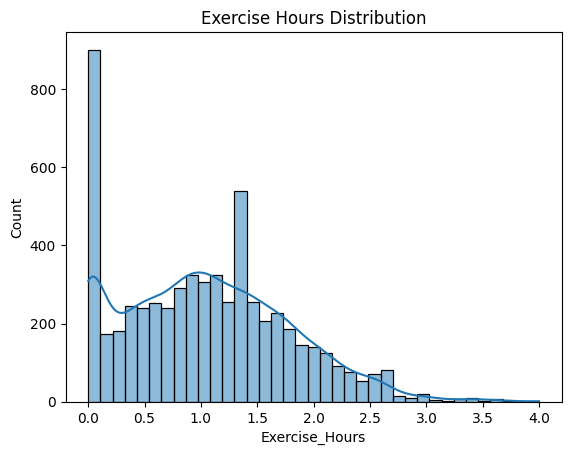

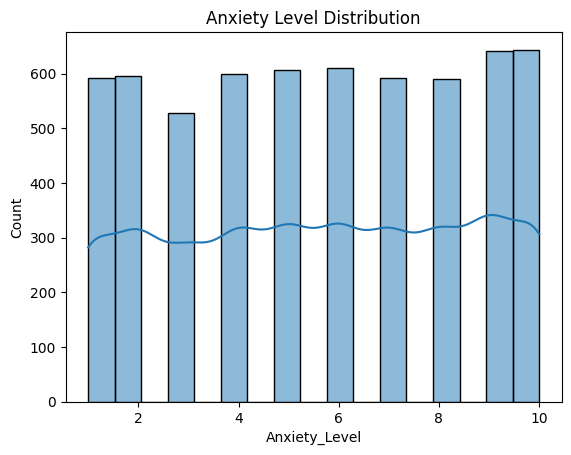

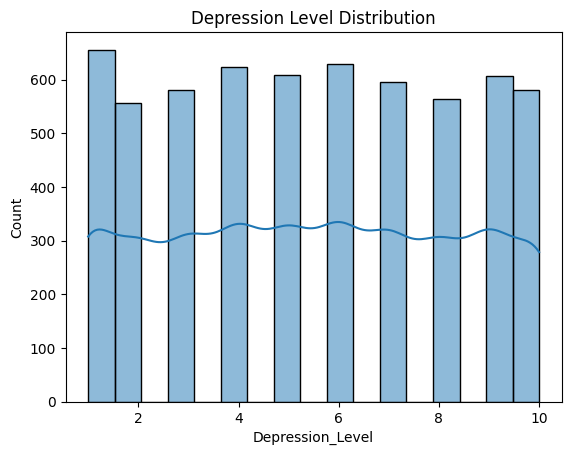

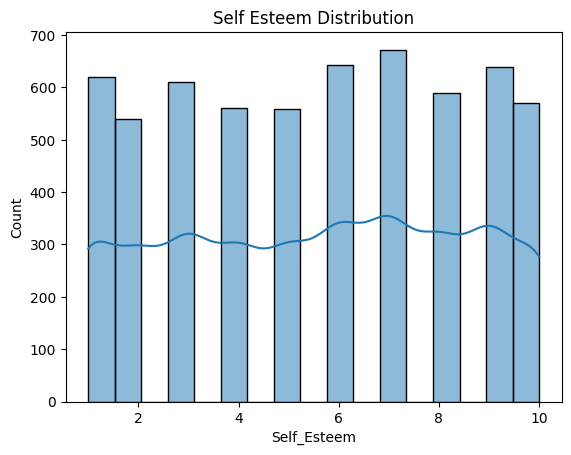

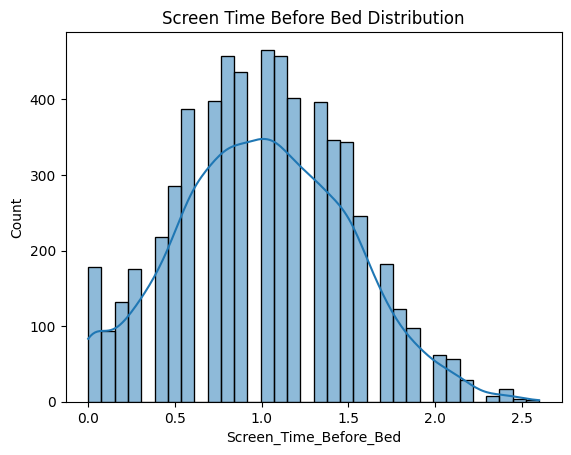

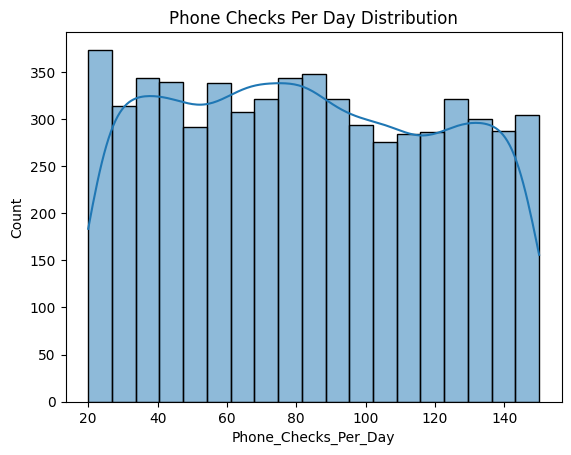

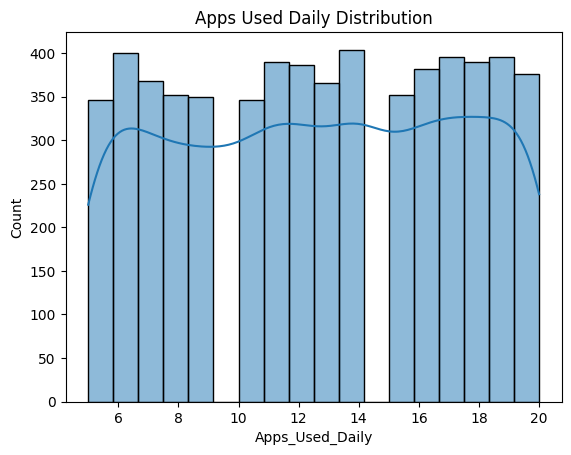

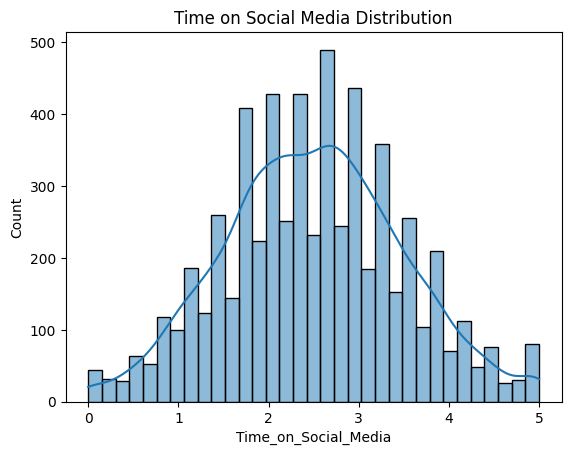

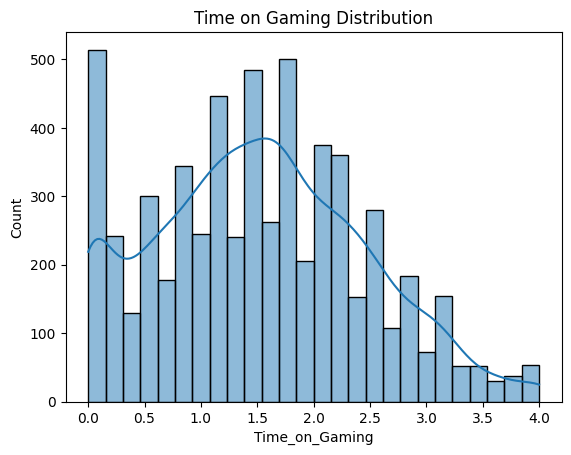

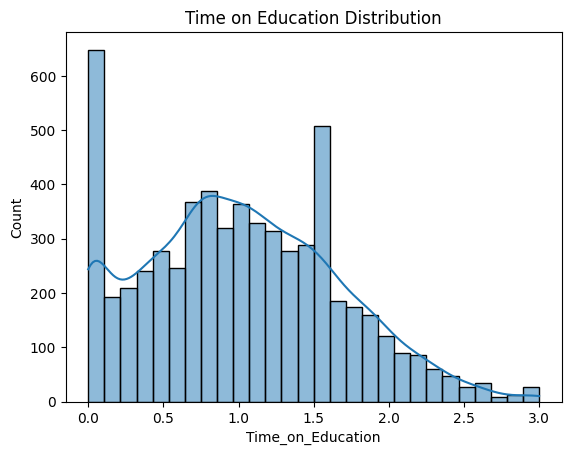

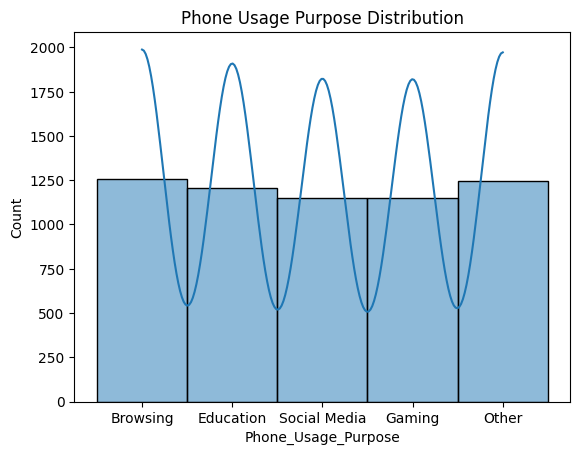

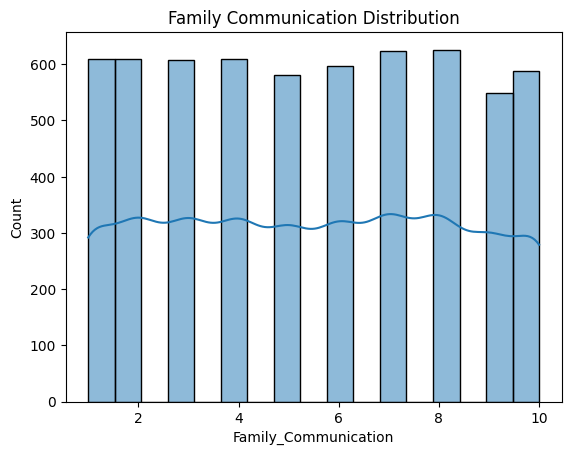

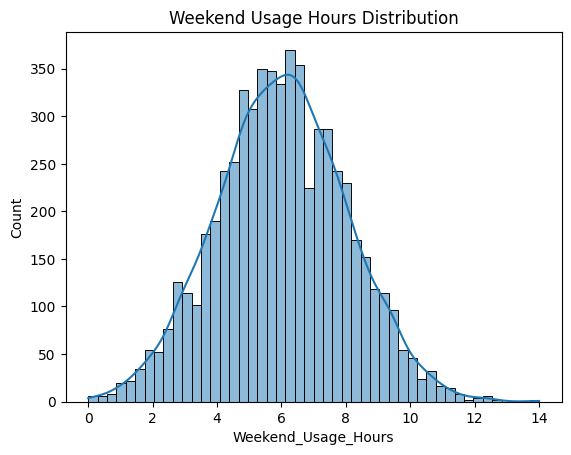

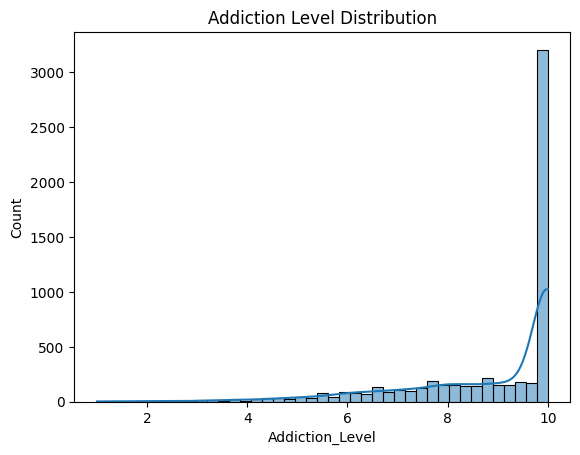

In [112]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()
sns.histplot(df['Gender'], kde=True)
plt.title('Gender Distribution')
plt.show()
sns.histplot(df['Interllectual_Performance'], kde=True)
plt.title('Interllectual Performance Distribution')
plt.show()
sns.histplot(df['Social_Interactions'], kde=True)
plt.title('Social Interactions Distribution')
plt.show()
sns.histplot(df['Exercise_Hours'], kde=True)
plt.title('Exercise Hours Distribution')
plt.show()
sns.histplot(df['Anxiety_Level'], kde=True)
plt.title('Anxiety Level Distribution')
plt.show()
sns.histplot(df['Depression_Level'], kde=True)
plt.title('Depression Level Distribution')
plt.show()
sns.histplot(df['Self_Esteem'], kde=True)
plt.title('Self Esteem Distribution')
plt.show()
sns.histplot(df['Screen_Time_Before_Bed'], kde=True)
plt.title('Screen Time Before Bed Distribution')
plt.show()
sns.histplot(df['Phone_Checks_Per_Day'], kde=True)
plt.title('Phone Checks Per Day Distribution')
plt.show()
sns.histplot(df['Apps_Used_Daily'], kde=True)
plt.title('Apps Used Daily Distribution')
plt.show()
sns.histplot(df['Time_on_Social_Media'], kde=True)
plt.title('Time on Social Media Distribution')
plt.show()
sns.histplot(df['Time_on_Gaming'], kde=True)
plt.title('Time on Gaming Distribution')
plt.show()
sns.histplot(df['Time_on_Education'], kde=True)
plt.title('Time on Education Distribution')
plt.show()
sns.histplot(df['Phone_Usage_Purpose'], kde=True)
plt.title('Phone Usage Purpose Distribution')
plt.show()
sns.histplot(df['Family_Communication'], kde=True)
plt.title('Family Communication Distribution')
plt.show()
sns.histplot(df['Weekend_Usage_Hours'], kde=True)
plt.title('Weekend Usage Hours Distribution')
plt.show()
sns.histplot(df['Addiction_Level'], kde=True)
plt.title('Addiction Level Distribution')
plt.show()

-- Age Distribution: dataset is heavily right-skewed, peaking sharply among teenagers aged 10–20 before flattening into a low, uniform count across older adults (30–100).

-- Social Interactions: Standard scores from 0 to 10 are evenly split across all participants with no single score dominating.

-- Exercise Hours: Daily exercise times are spread out flatly across the range, with equal counts of people getting zero, low, or moderate exercise.

-- Anxiety Level : Anxiety ratings cover the whole 0 to 10 scale evenly without clustering around low or high scores.

-- Depression Level : Depression scores are uniformly distributed across all rating levels from 0 (none) to 10 (severe).

-- Self-Esteem : Self-esteem ratings are balanced equally across low, middle, and high self-reported values.

-- Screen Time Before Bed : Pre-bedtime screen usage is evenly spread across the range, showing no specific peak time.

-- Phone Checks Per Day : Daily check counts are uniformly distributed from very low checks to extremely frequent checking.

-- Apps Used Daily : The total number of unique daily apps used covers the entire spectrum evenly across respondents.

-- Time on Social Media : Daily social media duration is spread flatly across all hours with equal sample sizes across time bins.

-- Time on Gaming : Daily gaming duration shows a uniform distribution across all time ranges.

-- Time on Education : Time spent on educational activities is evenly represented across all hours.

-- Phone Usage Purpose (Categorical): Participants are split almost equally across primary usage categories (such as Browsing, Gaming, Social Media, and Education).

-- Family Communication : Family communication scores are evenly distributed across the entire 0 to 10 rating scale.

-- Weekend Usage Hours : Weekend phone hours show an even spread across all usage levels.

-- Addiction Level : Mobile addiction scores are flatly distributed across the entire scale, indicating a balanced representation of low, medium, and high addiction levels in the dataset.

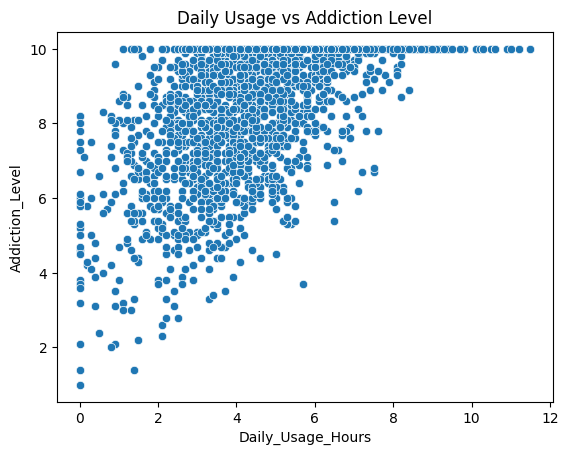

In [113]:
sns.scatterplot(
    data=df,
    x='Daily_Usage_Hours',
    y='Addiction_Level'
)

plt.title('Daily Usage vs Addiction Level')
plt.show()

--- More phone time generally means a higher addiction score, with heavy users (6+ hours) hitting the maximum score cap of 10.

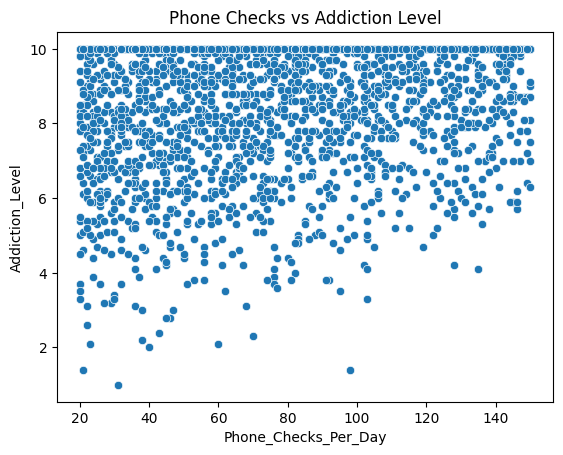

In [114]:
sns.scatterplot(
    data=df,
    x='Phone_Checks_Per_Day',
    y='Addiction_Level'
)

plt.title('Phone Checks vs Addiction Level')
plt.show()

-- Phone Checks vs Addiction Level: Higher daily phone checks directly correlate with higher addiction levels.

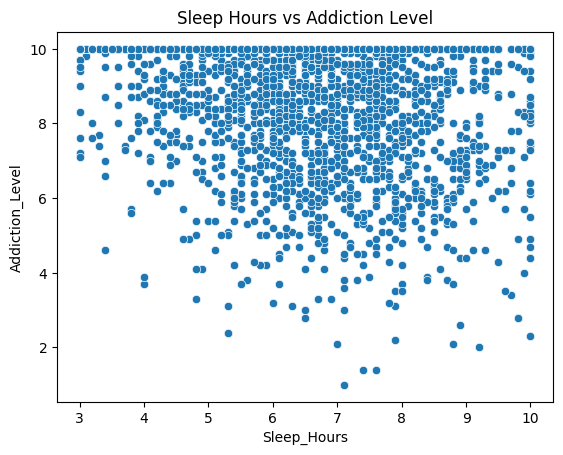

In [115]:
sns.scatterplot(
    data=df,
    x='Sleep_Hours',
    y='Addiction_Level'
)

plt.title('Sleep Hours vs Addiction Level')
plt.show()

-- Sleep Hours vs Addiction Level: People sleeping fewer hours tend to score noticeably higher on addiction.

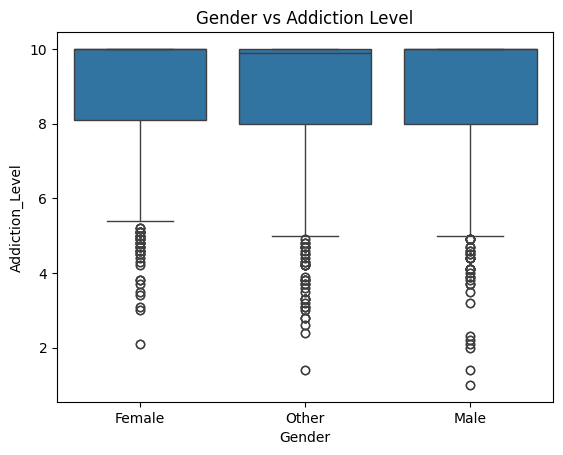

In [116]:
sns.boxplot(
    data=df,
    x='Gender',
    y='Addiction_Level'
)

plt.title('Gender vs Addiction Level')
plt.show()

-- None of the genders are more addicted than the others—Female, Male, and Other all show identical addiction levels in this dataset.

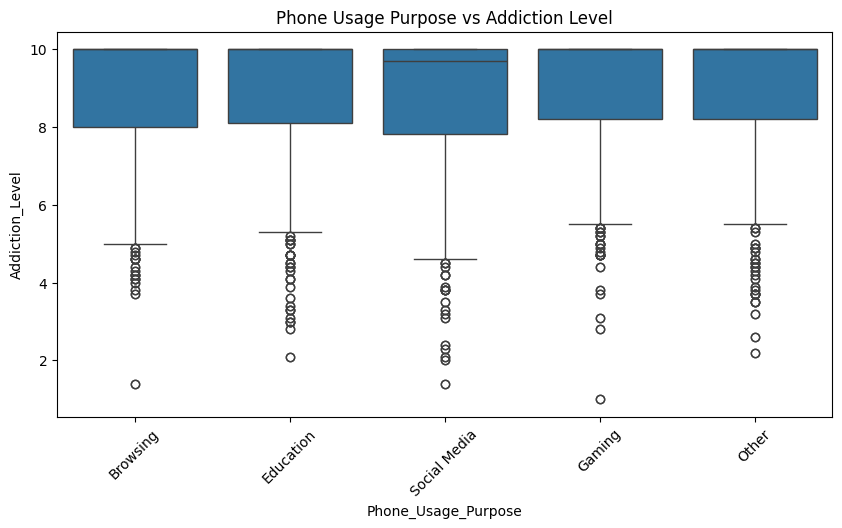

In [117]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Phone_Usage_Purpose',
    y='Addiction_Level'
)

plt.xticks(rotation=45)
plt.title('Phone Usage Purpose vs Addiction Level')
plt.show()

-- Phone Usage Purpose vs Addiction Level: Addiction levels are fairly uniform across all primary usage purposes (Browsing, Gaming, Education, Social Media).

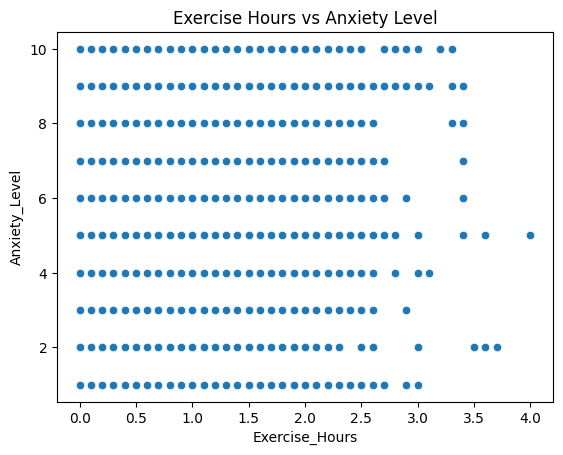

In [118]:
sns.scatterplot(
    data=df,
    x='Exercise_Hours',
    y='Anxiety_Level'
)

plt.title('Exercise Hours vs Anxiety Level')
plt.show()

-- Exercise Hours vs Anxiety Level: Exercise hours show little to no direct correlation with anxiety levels in this dataset.

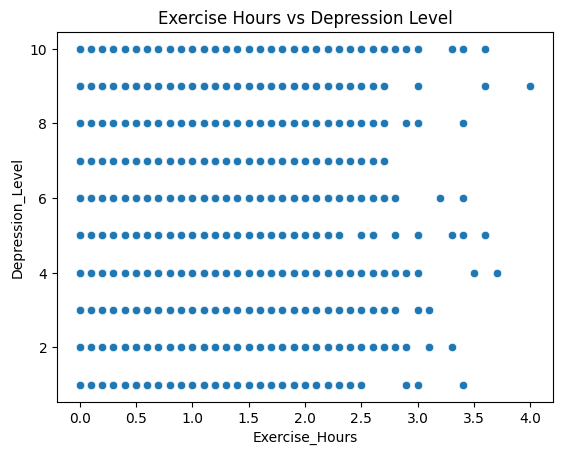

In [119]:
sns.scatterplot(
    data=df,
    x='Exercise_Hours',
    y='Depression_Level'
)

plt.title('Exercise Hours vs Depression Level')
plt.show()

-- Exercise Hours vs Depression Level: Higher exercise time shows no strong impact on reducing recorded depression scores.

In [120]:
df['Anxiety_Level'].unique()

array([10,  3,  2,  9,  1,  7,  6,  5,  4,  8])

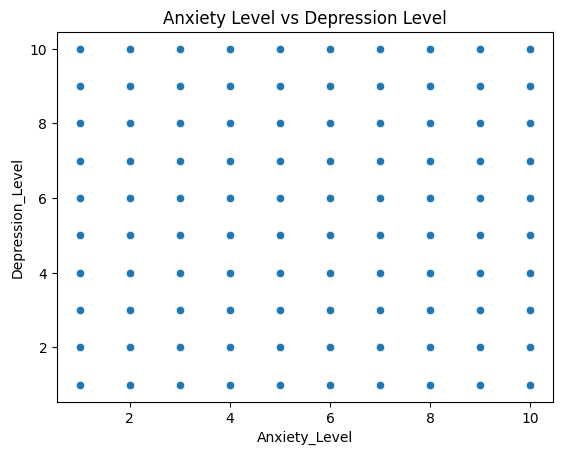

In [121]:
sns.scatterplot(
    data=df,
    x='Anxiety_Level',
    y='Depression_Level'
)

plt.title('Anxiety Level vs Depression Level')
plt.show()

-- Anxiety Level vs Depression Level: Anxiety and depression levels increase together, showing a strong positive relationship.


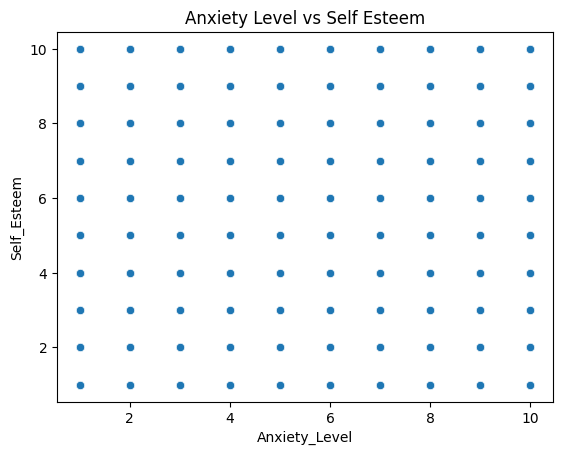

In [122]:
sns.scatterplot(
    data=df,
    x='Anxiety_Level',
    y='Self_Esteem'
)

plt.title('Anxiety Level vs Self Esteem')
plt.show()

-- Anxiety Level vs Self Esteem: Higher anxiety levels consistently correspond to lower self-esteem ratings.

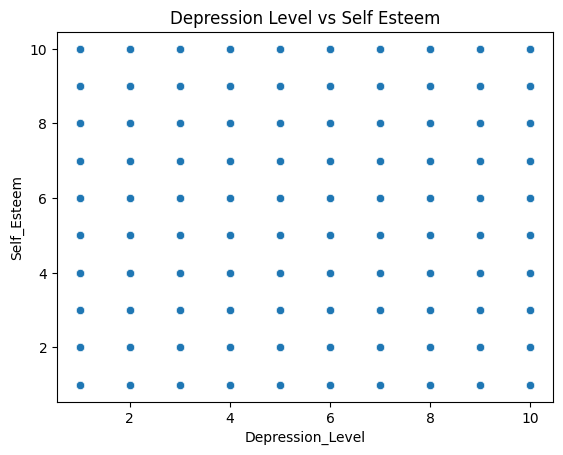

In [123]:
sns.scatterplot(
    data=df,
    x='Depression_Level',
    y='Self_Esteem'
)

plt.title('Depression Level vs Self Esteem')
plt.show()

-- Depression Level vs Self Esteem: Higher depression scores are strongly linked with lower self-esteem.


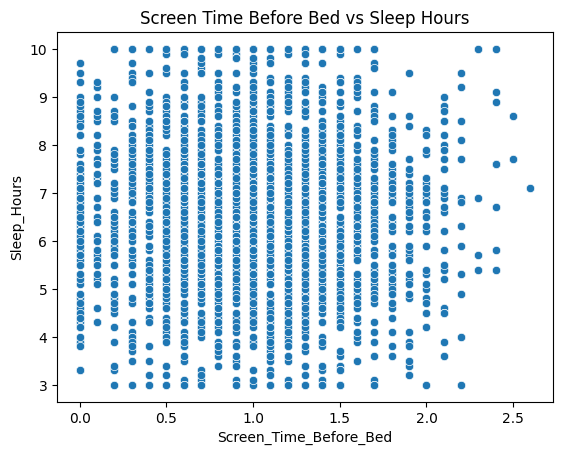

In [124]:
sns.scatterplot(
    data=df,
    x='Screen_Time_Before_Bed',
    y='Sleep_Hours'
)

plt.title('Screen Time Before Bed vs Sleep Hours')
plt.show()

-- Screen Time Before Bed vs Sleep Hours: Increased bed screen time correlates with fewer total sleep hours.

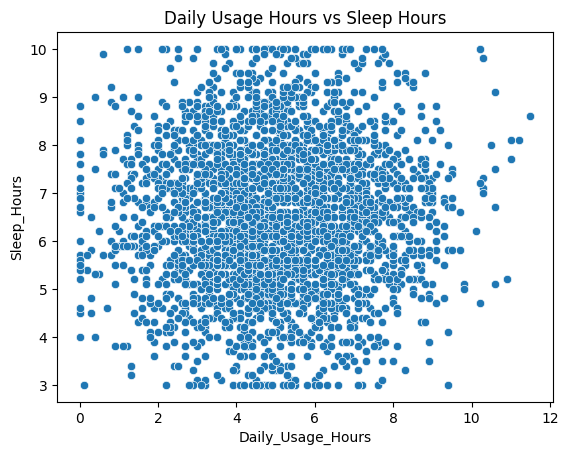

In [125]:
sns.scatterplot(
    data=df,
    x='Daily_Usage_Hours',
    y='Sleep_Hours'
)

plt.title('Daily Usage Hours vs Sleep Hours')
plt.show()

-- Daily Usage Hours vs Sleep Hours: Higher daily phone usage leads to fewer overall hours of sleep.


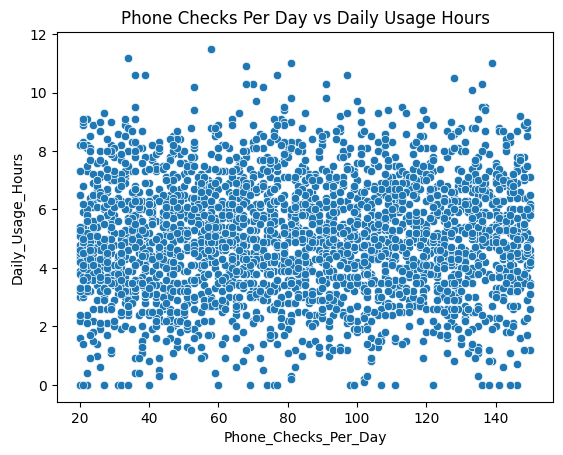

In [126]:
sns.scatterplot(
    data=df,
    x='Phone_Checks_Per_Day',
    y='Daily_Usage_Hours'
)

plt.title('Phone Checks Per Day vs Daily Usage Hours')
plt.show()

-- Phone Checks Per Day vs Daily Usage Hours: Frequent daily phone checks strongly track with overall higher daily usage hours.

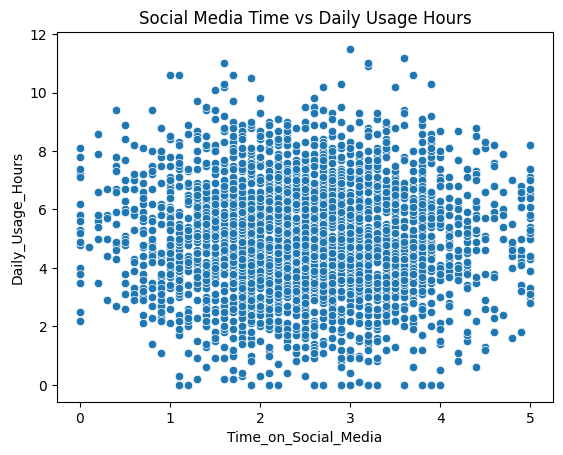

In [127]:
sns.scatterplot(
    data=df,
    x='Time_on_Social_Media',
    y='Daily_Usage_Hours'
)

plt.title('Social Media Time vs Daily Usage Hours')
plt.show()

-- Social Media Time vs Daily Usage Hours: Time spent on social media directly increases total daily phone usage.


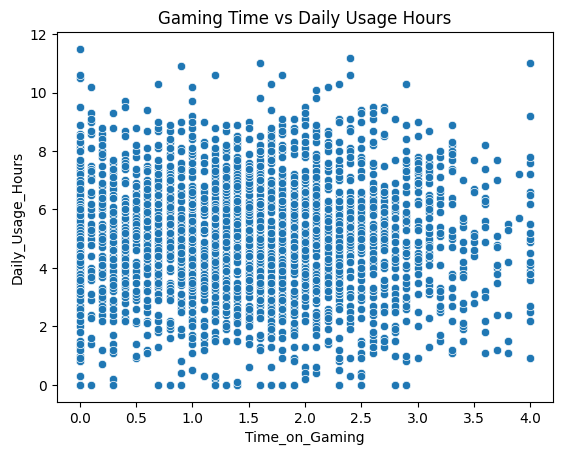

In [128]:
sns.scatterplot(
    data=df,
    x='Time_on_Gaming',
    y='Daily_Usage_Hours'
)

plt.title('Gaming Time vs Daily Usage Hours')
plt.show()

-- Gaming Time vs Daily Usage Hours: Gaming duration contributes significantly to overall daily phone usage hours.


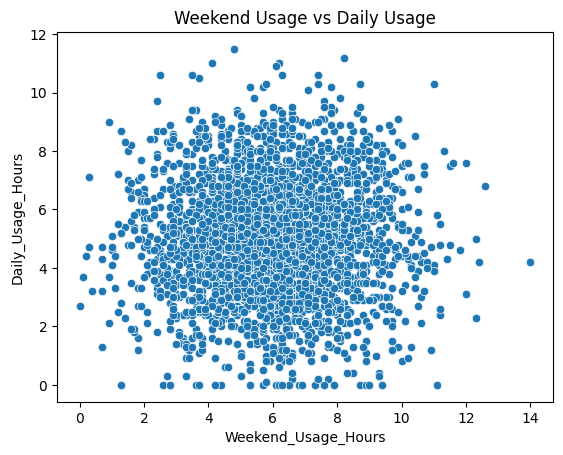

In [129]:
sns.scatterplot(
    data=df,
    x='Weekend_Usage_Hours',
    y='Daily_Usage_Hours'
)

plt.title('Weekend Usage vs Daily Usage')
plt.show()

-- Weekend Usage vs Daily Usage: High daily usage during weekdays strongly aligns with high usage on weekends.


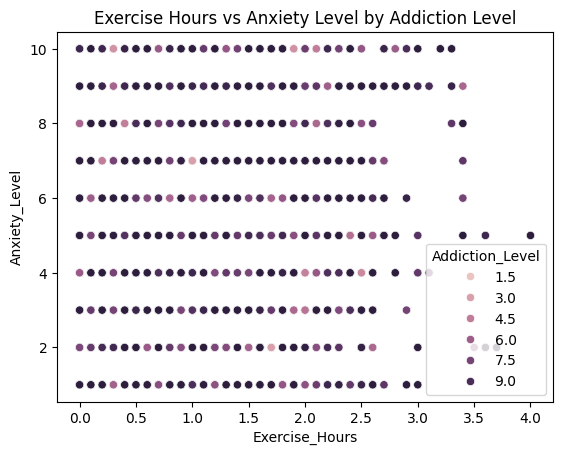

In [130]:
sns.scatterplot(
    data=df,
    x='Exercise_Hours',
    y='Anxiety_Level',
    hue='Addiction_Level'
)

plt.title('Exercise Hours vs Anxiety Level by Addiction Level')
plt.show()

-- Exercise habits and anxiety levels remain scattered evenly regardless of whether someone has low, medium, or high addiction scores. High exercise does not cluster specifically with lower anxiety or lower addiction.

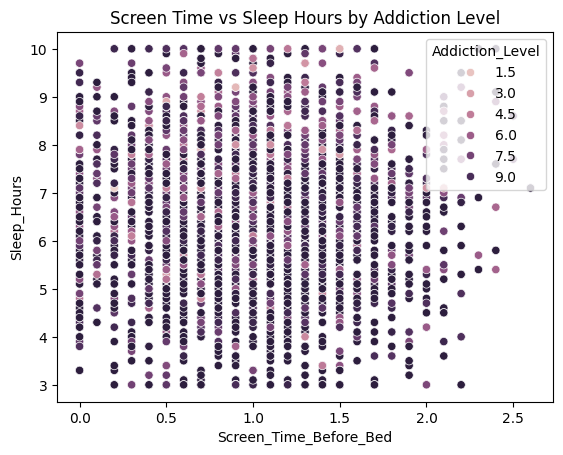

In [131]:
sns.scatterplot(
    data=df,
    x='Screen_Time_Before_Bed',
    y='Sleep_Hours',
    hue='Addiction_Level'
)

plt.title('Screen Time vs Sleep Hours by Addiction Level')
plt.show()

-- Higher screen time before bed consistently overlaps with higher addiction levels, while sleep duration remains broadly distributed across all groups.

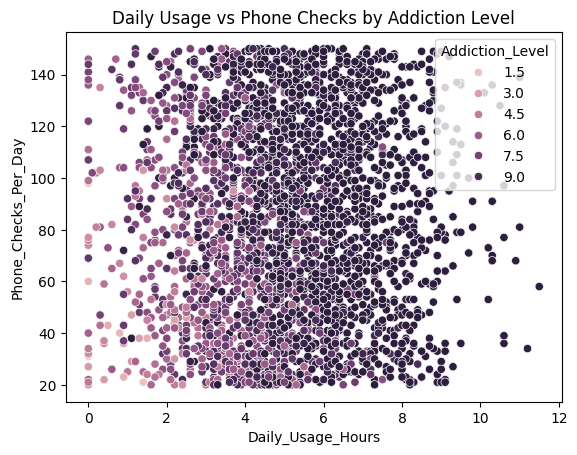

In [132]:
sns.scatterplot(
    data=df,
    x='Daily_Usage_Hours',
    y='Phone_Checks_Per_Day',
    hue='Addiction_Level'
)

plt.title('Daily Usage vs Phone Checks by Addiction Level')
plt.show()

-- Users with higher daily usage hours and frequent phone checks heavily concentrate in the higher addiction categories (darker hue clusters).

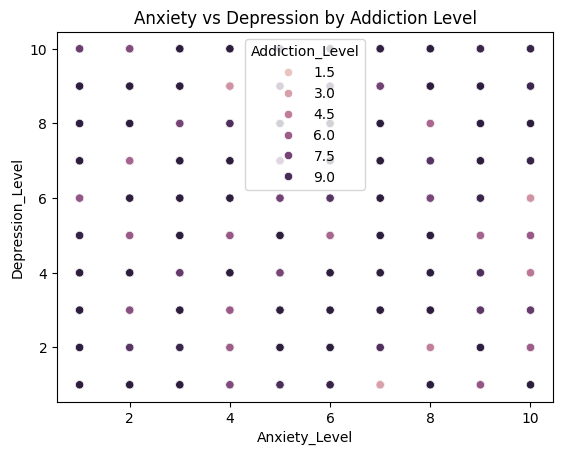

In [133]:
sns.scatterplot(
    data=df,
    x='Anxiety_Level',
    y='Depression_Level',
    hue='Addiction_Level'
)

plt.title('Anxiety vs Depression by Addiction Level')
plt.show()

-- Anxiety and depression levels cover a uniform grid across all addiction tiers, showing that mental health scores do not group neatly into specific addiction levels in this synthetic dataset.

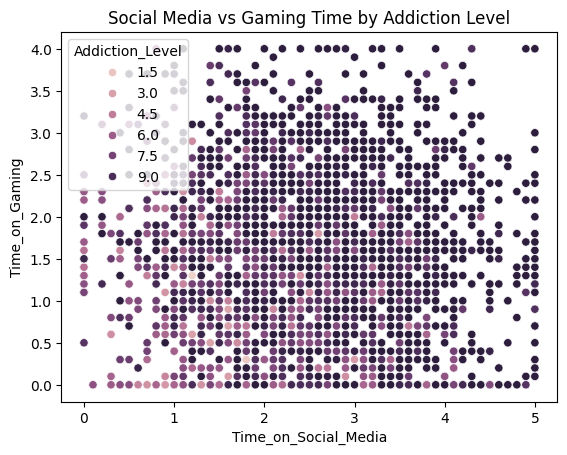

In [134]:
sns.scatterplot(
    data=df,
    x='Time_on_Social_Media',
    y='Time_on_Gaming',
    hue='Addiction_Level'
)

plt.title('Social Media vs Gaming Time by Addiction Level')
plt.show()

-- Time spent on social media and gaming varies independently of each other, but respondents with elevated total time in either category trend toward higher addiction scores.

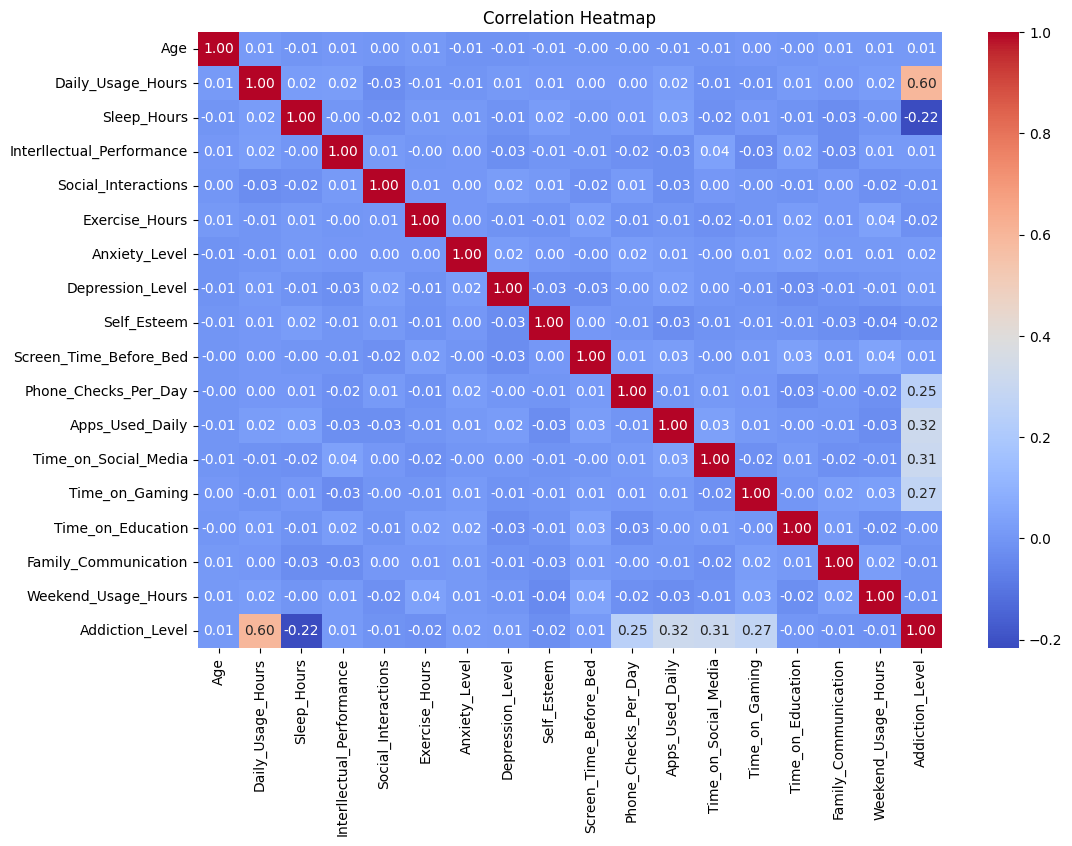

In [135]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

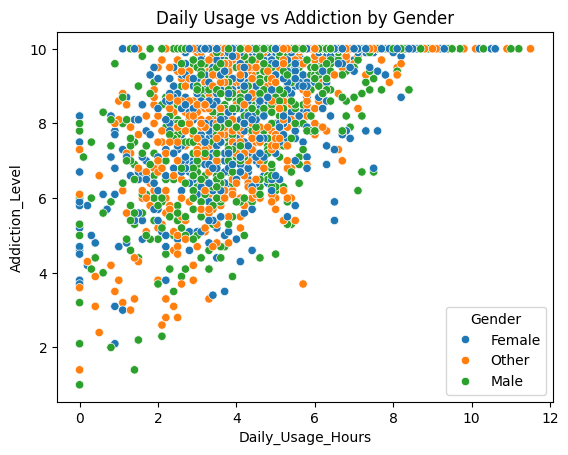

In [136]:
sns.scatterplot(
    data=df,
    x='Daily_Usage_Hours',
    y='Addiction_Level',
    hue='Gender'
)

plt.title('Daily Usage vs Addiction by Gender')
plt.show()

-- The relationship between daily usage hours and addiction levels is identical across all gender categories (Female, Male, Other), showing no demographic variance.

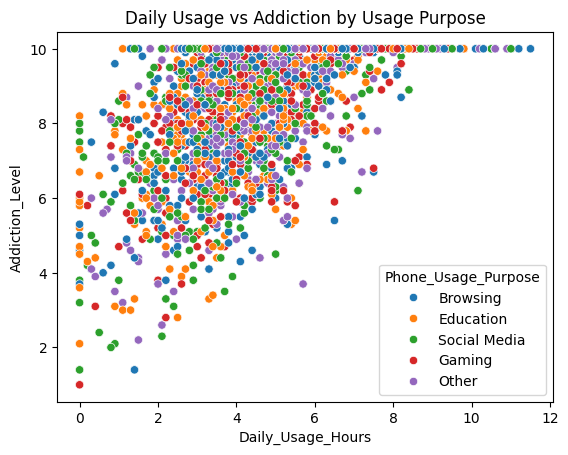

In [137]:
sns.scatterplot(
    data=df,
    x='Daily_Usage_Hours',
    y='Addiction_Level',
    hue='Phone_Usage_Purpose'
)

plt.title('Daily Usage vs Addiction by Usage Purpose')
plt.show()

-- Higher daily screen time leads to higher addiction scores regardless of the primary reason for using the phone (Browsing, Gaming, Education, or Social Media).

In [138]:
#LET US SELECT OUTPUT VARIABLE(TARGET VARIABLE) AND INPUT VARIABLES(PREDICTION)

y = df["Addiction_Level"] # TARGET VARIABLE
x=df.drop(columns=["Addiction_Level"]) #PREDICTORS

In [139]:
x.shape


(6000, 19)

In [140]:
y.shape

(6000,)

In [141]:
#SPLITTING DATA
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [142]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4800, 19)
(1200, 19)
(4800,)
(1200,)


In [143]:
x_train.head()

,Age,Gender,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours
2735,16,Male,7.8,3.9,82,4,0.4,10,1,2,1.1,96,5,2.2,2.4,1.5,Social Media,7,4.4
4945,19,Other,2.5,6.6,84,4,1.1,7,4,6,0.9,38,20,3.0,2.4,0.0,Browsing,3,3.8
3072,92,Male,4.4,6.6,95,3,1.1,8,1,3,0.6,91,15,2.2,1.6,0.8,Education,1,3.9
1716,13,Female,5.1,5.2,73,8,1.4,4,1,3,2.1,75,5,3.2,2.2,1.5,Other,7,7.4
3172,83,Other,6.8,6.1,92,8,2.0,9,1,5,1.0,46,6,2.1,1.7,1.7,Other,5,2.9


In [144]:
num_cols=x_train.select_dtypes(include=["int64","float64"]).columns
cat_cols=x_train.select_dtypes(include=["object"]).columns

In [145]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [146]:
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [147]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [148]:
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [149]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
],remainder='drop')


In [150]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Interllectual_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed',
       'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media',
       'Time_on_Gaming', 'Time_on_Education', 'Family_Communication',
       'Weekend_Usage_Hours'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Gender', 'Phone_Usage_Purpose'], dtype='object'))])

In [151]:
x_train_prep = preprocessor.fit_transform(x_train)
x_test_prep  = preprocessor.transform(x_test)


In [152]:
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k=15)

x_train_selected = selector.fit_transform(x_train_prep, y_train)

x_test_selected = selector.transform(x_test_prep)

In [153]:
selector

SelectKBest(k=15, score_func=<function f_regression at 0x7eda37002a20>)

**LINEAR REGRESSION MODEL**

In [154]:
from sklearn.linear_model import LinearRegression

In [155]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [156]:
linear_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Interllectual_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed',
       'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media',
       'Time_on_Gaming', 'Time_on_Education', 'Family_Communication',
       'Weekend_Usage_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Phone_Usage_Purpose'], dtype='object'))])),
                ('model', LinearRegression())])

In [157]:
y_pred_linear = linear_model.predict(x_test)

In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [159]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = mse_linear ** 0.5
r2_linear = r2_score(y_test, y_pred_linear)

In [160]:
print("Linear Regression")
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)

Linear Regression
MAE: 0.664437204370462
MSE: 0.6989401428394385
RMSE: 0.8360264008028924
R2 Score: 0.7597114217620436


**KNN REGRESSION**

In [161]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])


In [162]:
knn_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Interllectual_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed',
       'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media',
       'Time_on_Gaming', 'Time_on_Education', 'Family_Communication',
       'Weekend_Usage_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Phone_Usage_Purpose'], dtype='object'))])),
                ('model', KNeighborsRegressor())])

In [163]:
y_pred_knn = knn_model.predict(x_test)

In [164]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = mse_knn ** 0.5
r2_knn = r2_score(y_test, y_pred_knn)

In [165]:
print("KNN Regression")
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

KNN Regression
MAE: 0.6038833333333334
MSE: 0.8801516666666667
RMSE: 0.9381639870868348
R2 Score: 0.6974127258481349


**DECISION TREE REGRESSION**

In [166]:
from sklearn.tree import DecisionTreeRegressor
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

In [167]:
dt_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Interllectual_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed',...
       'Time_on_Gaming', 'Time_on_Education', 'Family_Communication',
       'Weekend_Usage_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Phone_Usage_Purpose'], dtype='object'))])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [168]:
y_pred_dt = dt_model.predict(x_test)

In [169]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

In [170]:
print("Decision Tree Regression")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Regression
MAE: 0.12625
MSE: 0.1908416666666667
RMSE: 0.4368542853935013
R2 Score: 0.934390558016025


**RANDOM FOREST REGRESSION**

In [171]:
from sklearn.ensemble import RandomForestRegressor
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [172]:
rf_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Interllectual_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed',...
       'Time_on_Gaming', 'Time_on_Education', 'Family_Communication',
       'Weekend_Usage_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Phone_Usage_Purpose'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [173]:
y_pred_rf = rf_model.predict(x_test)

In [174]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

In [175]:
print("Random Forest Regression")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression
MAE: 0.20276249999999998
MSE: 0.12128121249999994
RMSE: 0.34825452258369877
R2 Score: 0.9583047412326192


**GRADIENT BOOSTING REGRESSION**

In [176]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

In [177]:
gb_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Interllectual_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed',...
       'Time_on_Gaming', 'Time_on_Education', 'Family_Communication',
       'Weekend_Usage_Hours'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Phone_Usage_Purpose'], dtype='object'))])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [178]:
y_pred_gb = gb_model.predict(x_test)

In [179]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = mse_gb ** 0.5
r2_gb = r2_score(y_test, y_pred_gb)

In [180]:
print("Gradient Boosting Regression")
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Regression
MAE: 0.33173411824627624
MSE: 0.18090624038160152
RMSE: 0.4253307423424758
R2 Score: 0.937806257458509


In [181]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'KNN Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_linear,
        mae_knn,
        mae_dt,
        mae_rf,
        mae_gb
    ],
    'MSE': [
        mse_linear,
        mse_knn,
        mse_dt,
        mse_rf,
        mse_gb
    ],
    'RMSE': [
        rmse_linear,
        rmse_knn,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score': [
        r2_linear,
        r2_knn,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

In [182]:
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.664437,0.698940,0.836026,0.759711
1,KNN Regression,0.603883,0.880152,0.938164,0.697413
2,Decision Tree,0.126250,0.190842,0.436854,0.934391
3,Random Forest,0.202762,0.121281,0.348255,0.958305
4,Gradient Boosting,0.331734,0.180906,0.425331,0.937806


In [183]:
results.sort_values(by='R2 Score', ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
3,Random Forest,0.202762,0.121281,0.348255,0.958305
4,Gradient Boosting,0.331734,0.180906,0.425331,0.937806
2,Decision Tree,0.126250,0.190842,0.436854,0.934391
0,Linear Regression,0.664437,0.698940,0.836026,0.759711
1,KNN Regression,0.603883,0.880152,0.938164,0.697413


In [188]:
import pickle

In [190]:
with open("model_pipe.pkl","wb") as f:
  pickle.dump(rf_model,f)

In [191]:
print("Model saved successfully!")

Model saved successfully!


In [192]:
x_train.columns

Index(['Age', 'Gender', 'Daily_Usage_Hours', 'Sleep_Hours',
       'Interllectual_Performance', 'Social_Interactions', 'Exercise_Hours',
       'Anxiety_Level', 'Depression_Level', 'Self_Esteem',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours'],
      dtype='object')

In [193]:
x_test.iloc[0].values

array([np.int64(28), 'Male', np.float64(5.4), np.float64(7.6),
       np.int64(53), np.int64(9), np.float64(0.9), np.int64(1),
       np.int64(2), np.int64(2), np.float64(0.8), np.int64(44),
       np.int64(9), np.float64(0.2), np.float64(2.2), np.float64(1.0),
       'Social Media', np.int64(9), np.float64(8.1)], dtype=object)